# Examen de cinturón AML – Opción A

Descripción del examen:
En este examen, trabajarás con un dataset reciente de complejidad baja, donde primero realizarás un análisis no supervisado utilizando K-means o PCA, y luego modelarás el conjunto de datos utilizando un Perceptrón Multicapa (MLP). El objetivo es aplicar técnicas de clustering o reducción de dimensionalidad para analizar los datos, seguido de la implementación de un modelo MLP para realizar predicciones.

Dataset:
El dataset utilizado para este examen es el «Customer Personality Analysis» disponible en Kaggle. Este conjunto de datos contiene información demográfica y de comportamiento de clientes, con el objetivo de agruparlos y predecir sus patrones de compra.
Enlace al dataset: https://www.kaggle.com/imakash3011/customer-personality-analysis 

## About Dataset

Context

Problem Statement

Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

## Content

Attributes

People


- **ID**: Customer's unique identifier
- **Year_Birth**: Customer's birth year
- **Education**: Customer's education level
- **Marital_Status**: Customer's marital status
- **Income**: Customer's yearly household income
- **Kidhome**: Number of children in customer's household
- **Teenhome**: Number of teenagers in customer's household
- **Dt_Customer**: Date of customer's enrollment with the company
- **Recency**: Number of days since customer's last purchase
- **Complain**: 1 if the customer complained in the last 2 years, 0 otherwise

### Products

- **MntWines**: Amount spent on wine in last 2 years
- **MntFruits**: Amount spent on fruits in last 2 years
- **MntMeatProducts**: Amount spent on meat in last 2 years
- **MntFishProducts**: Amount spent on fish in last 2 years
- **MntSweetProducts**: Amount spent on sweets in last 2 years
- **MntGoldProds**: Amount spent on gold in last 2 years

### Promotion

- **NumDealsPurchases**: Number of purchases made with a discount
- **AcceptedCmp1**: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- **AcceptedCmp2**: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- **AcceptedCmp3**: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- **AcceptedCmp4**: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- **AcceptedCmp5**: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- **Response**: 1 if customer accepted the offer in the last campaign, 0 otherwise

### Place

- **NumWebPurchases**: Number of purchases made through the company’s website
- **NumCatalogPurchases**: Number of purchases made using a catalogue
- **NumStorePurchases**: Number of purchases made directly in stores
- **NumWebVisitsMonth**: Number of visits to company’s website in the last month

In [1]:
### Configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import utils


# 1. Exploración y preprocesamiento de datos:

  – Carga y explora el dataset para identificar las variables más relevantes. Las características incluyen información demográfica como la edad, el ingreso, el estado civil, y datos de comportamiento de compra, como la cantidad gastada en diferentes productos.

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

# List files in the directory to find the correct CSV file
files = os.listdir(path)
print(files)

# Assuming the CSV file is named 'marketing_campaign.csv' (replace with the actual file name)
csv_file = os.path.join(path, 'marketing_campaign.csv')

# Load dataset  
df = pd.read_csv(csv_file, sep='\t')
df.head().T

c:\Users\Gonzalo\anaconda3\envs\mitic-data-science-setiembre-2024\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['marketing_campaign.csv']


,0,1,2,3,4
ID,5524,2174,4141,6182,5324
Year_Birth,1957,1954,1965,1984,1981
Education,Graduation,Graduation,Graduation,Graduation,PhD
Marital_Status,Single,Single,Together,Together,Married
Income,58138.0,46344.0,71613.0,26646.0,58293.0
Kidhome,0,1,0,1,1
Teenhome,0,1,0,0,0
Dt_Customer,04-09-2012,08-03-2014,21-08-2013,10-02-2014,19-01-2014
Recency,58,38,26,26,94
MntWines,635,11,426,11,173


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

  – Asegúrate de manejar los valores nulos y realizar un preprocesamiento adecuado, como la normalización de los datos para el análisis posterior.

In [4]:
# Verificación de valores nulos
utils.calculate_na_statistics(df)

,datos sin NAs en q,Na en q,Na en %
Income,2216,24,1.07
ID,2240,0,0.00
NumDealsPurchases,2240,0,0.00
Z_Revenue,2240,0,0.00
Z_CostContact,2240,0,0.00
Complain,2240,0,0.00
AcceptedCmp2,2240,0,0.00
AcceptedCmp1,2240,0,0.00
AcceptedCmp5,2240,0,0.00
AcceptedCmp4,2240,0,0.00


Como es tan baja la proporcion de nulos en Income, podemos eliminarlos del dataset

In [5]:
df.dropna(inplace=True)

In [6]:
utils.calculate_na_statistics(df)

,datos sin NAs en q,Na en q,Na en %
ID,2216,0,0.0
NumDealsPurchases,2216,0,0.0
Z_Revenue,2216,0,0.0
Z_CostContact,2216,0,0.0
Complain,2216,0,0.0
AcceptedCmp2,2216,0,0.0
AcceptedCmp1,2216,0,0.0
AcceptedCmp5,2216,0,0.0
AcceptedCmp4,2216,0,0.0
AcceptedCmp3,2216,0,0.0


In [7]:
# Verificación de valores duplicados
df.duplicated().sum()

0

No hay valores duplicados.

Verificación y ajuste de tipos de datos

In [8]:
# Diccionario de datos para modificar los tipos de datos
data_types = {
    'ID': 'int64',
    'Year_Birth': 'datetime64[ns]',
    'Education': 'category',
    'Marital_Status': 'category',
    'Income': 'float64',
    'Kidhome': 'int64',
    'Teenhome': 'int64',
    'Dt_Customer': 'datetime64[ns]',
    'Recency': 'int64',
    'Complain': 'bool',
    'MntWines': 'float64',
    'MntFruits': 'float64',
    'MntMeatProducts': 'float64',
    'MntFishProducts': 'float64',
    'MntSweetProducts': 'float64',
    'MntGoldProds': 'float64',
    'NumDealsPurchases': 'int64',
    'AcceptedCmp1': 'bool',
    'AcceptedCmp2': 'bool',
    'AcceptedCmp3': 'bool',
    'AcceptedCmp4': 'bool',
    'AcceptedCmp5': 'bool',
    'Response': 'bool',
    'NumWebPurchases': 'int64',
    'NumCatalogPurchases': 'int64',
    'NumStorePurchases': 'int64',
    'NumWebVisitsMonth': 'int64'
}

# Aplicar los tipos de datos al DataFrame
df = df.astype(data_types)

# Verificar los cambios
print(df.dtypes)

ID                              int64
Year_Birth             datetime64[ns]
Education                    category
Marital_Status               category
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                      float64
MntFruits                     float64
MntMeatProducts               float64
MntFishProducts               float64
MntSweetProducts              float64
MntGoldProds                  float64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                     bool
AcceptedCmp4                     bool
AcceptedCmp5                     bool
AcceptedCmp1                     bool
AcceptedCmp2                     bool
Complain                         bool
Z_CostContac

Verificación de la consistencia en valores categóricos


In [9]:
# Verificar valores únicos en columnas categóricas
categorical_columns = ['Education', 'Marital_Status']

for col in categorical_columns:
	print(f"\nValores únicos en {col}:")
	print(df[col].value_counts())



Valores únicos en Education:
Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

Valores únicos en Marital_Status:
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [10]:
# Eliminar filas con valores no validos en Marital_Status
df = df[~df['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO'])]

# Verificar los cambios
print(df['Marital_Status'].value_counts())

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Absurd        0
Alone         0
YOLO          0
Name: count, dtype: int64


- Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual

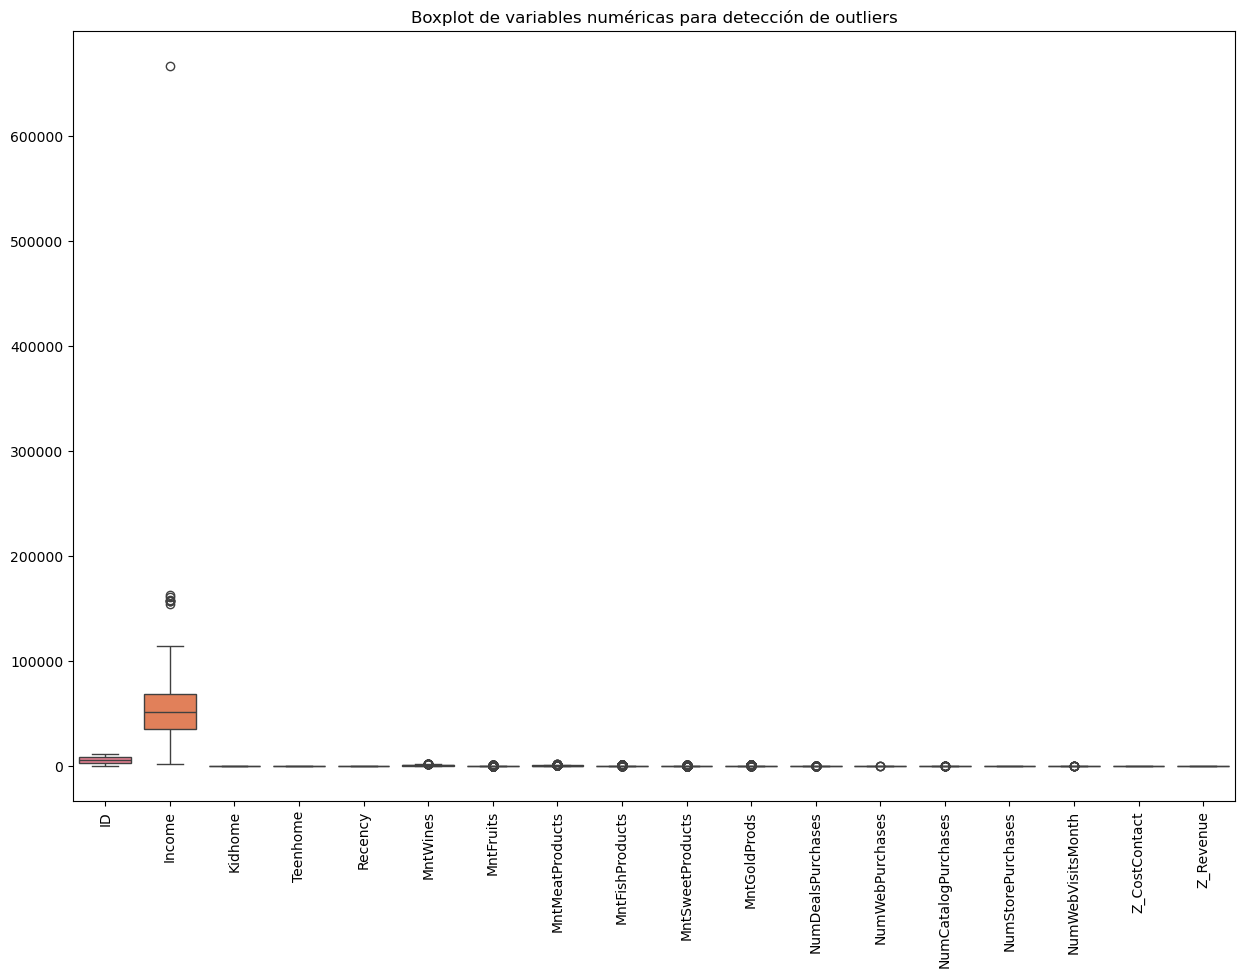

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1970-01-01 00:00:00.000001973,PhD,Married,157243.0,0,1,2014-01-03,98,20.0,...,0,False,False,False,False,False,False,3,11,False
617,1503,1970-01-01 00:00:00.000001976,PhD,Together,162397.0,1,1,2013-03-06,31,85.0,...,1,False,False,False,False,False,False,3,11,False
655,5555,1970-01-01 00:00:00.000001975,Graduation,Divorced,153924.0,0,0,2014-07-02,81,1.0,...,0,False,False,False,False,False,False,3,11,False
687,1501,1970-01-01 00:00:00.000001982,PhD,Married,160803.0,0,0,2012-04-08,21,55.0,...,0,False,False,False,False,False,False,3,11,False
1300,5336,1970-01-01 00:00:00.000001971,Master,Together,157733.0,1,0,2013-04-06,37,39.0,...,1,False,False,False,False,False,False,3,11,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,10749,1970-01-01 00:00:00.000001991,Graduation,Single,8028.0,0,0,2012-09-18,62,73.0,...,19,False,False,False,False,False,False,3,11,False
1245,6862,1970-01-01 00:00:00.000001971,Graduation,Divorced,1730.0,0,0,2014-05-18,65,1.0,...,20,False,False,False,False,False,False,3,11,False
1328,4246,1970-01-01 00:00:00.000001982,Master,Single,6560.0,0,0,2013-12-12,2,67.0,...,17,False,False,False,False,False,False,3,11,False
1524,11110,1970-01-01 00:00:00.000001973,Graduation,Single,3502.0,1,0,2013-04-13,56,2.0,...,14,False,False,False,False,False,False,3,11,False


In [11]:
# Visualización de datos anómalos utilizando boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.title('Boxplot de variables numéricas para detección de outliers')
plt.show()

# Función para detectar outliers usando el método IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
    return outliers

# Columnas numéricas a evaluar
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
outliers = pd.DataFrame()

for col in numeric_columns:
    outliers = pd.concat([outliers, detect_outliers(df, col)])

outliers

En el gráfico de boxplot se observa que la variable que tiene mayor cantidad de outliers es Income, por lo que procederemos a analizarla

In [12]:
# Detectar outliers en la columna Income
income_outliers = detect_outliers(df, 'Income')
income_outliers.T

,164,617,655,687,1300,1653,2132,2233
ID,8475,1503,5555,1501,5336,4931,11181,9432
Year_Birth,1970-01-01 00:00:00.000001973,1970-01-01 00:00:00.000001976,1970-01-01 00:00:00.000001975,1970-01-01 00:00:00.000001982,1970-01-01 00:00:00.000001971,1970-01-01 00:00:00.000001977,1970-01-01 00:00:00.000001949,1970-01-01 00:00:00.000001977
Education,PhD,PhD,Graduation,PhD,Master,Graduation,PhD,Graduation
Marital_Status,Married,Together,Divorced,Married,Together,Together,Married,Together
Income,157243.0,162397.0,153924.0,160803.0,157733.0,157146.0,156924.0,666666.0
Kidhome,0,1,0,0,1,0,0,1
Teenhome,1,1,0,0,0,0,0,0
Dt_Customer,2014-01-03 00:00:00,2013-03-06 00:00:00,2014-07-02 00:00:00,2012-04-08 00:00:00,2013-04-06 00:00:00,2013-04-29 00:00:00,2013-08-29 00:00:00,2013-02-06 00:00:00
Recency,98,31,81,21,37,13,85,23
MntWines,20.0,85.0,1.0,55.0,39.0,1.0,2.0,9.0


In [13]:
income_outliers.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Z_CostContact,Z_Revenue
count,8.000000,8,8.000000,8.000000,8.00000,8,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.00000,8.0,8.0
mean,5989.250000,1970-01-01 00:00:00.000001972,221604.500000,0.375000,0.25000,2013-05-30 21:00:00,48.625000,26.500000,4.500000,621.875000,4.250000,1.250000,3.750000,4.250000,0.500000,9.87500,0.750000,1.12500,3.0,11.0
min,1501.000000,1970-01-01 00:00:00.000001949,153924.000000,0.000000,0.00000,2012-04-08 00:00:00,13.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.00000,3.0,11.0
25%,4074.000000,1970-01-01 00:00:00.000001972,157090.500000,0.000000,0.00000,2013-02-27 00:00:00,22.500000,1.750000,1.000000,7.250000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.00000,3.0,11.0
50%,5445.500000,1970-01-01 00:00:00.000001975,157488.000000,0.000000,0.00000,2013-04-17 12:00:00,34.000000,14.500000,1.000000,17.000000,2.000000,1.000000,1.500000,0.000000,0.000000,0.50000,0.500000,0.50000,3.0,11.0
75%,8714.250000,1970-01-01 00:00:00.000001977,161201.500000,1.000000,0.25000,2013-09-29 18:00:00,82.000000,43.000000,5.000000,1592.000000,3.500000,1.250000,5.000000,6.750000,0.250000,23.50000,1.000000,1.00000,3.0,11.0
max,11181.000000,1970-01-01 00:00:00.000001982,666666.000000,1.000000,1.00000,2014-07-02 00:00:00,98.000000,85.000000,16.000000,1725.000000,17.000000,3.000000,12.000000,15.000000,3.000000,28.00000,3.000000,6.00000,3.0,11.0
std,3525.251308,NaN,179850.404431,0.517549,0.46291,NaN,33.687376,30.798887,6.524678,846.511402,5.650537,0.886405,4.131759,6.777062,1.069045,13.48478,1.035098,2.03101,0.0,0.0


In [14]:
# Hacer drop de los outliers de la columna income
df = df[~df['ID'].isin(income_outliers['ID'])]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2201 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2201 non-null   int64         
 1   Year_Birth           2201 non-null   datetime64[ns]
 2   Education            2201 non-null   category      
 3   Marital_Status       2201 non-null   category      
 4   Income               2201 non-null   float64       
 5   Kidhome              2201 non-null   int64         
 6   Teenhome             2201 non-null   int64         
 7   Dt_Customer          2201 non-null   datetime64[ns]
 8   Recency              2201 non-null   int64         
 9   MntWines             2201 non-null   float64       
 10  MntFruits            2201 non-null   float64       
 11  MntMeatProducts      2201 non-null   float64       
 12  MntFishProducts      2201 non-null   float64       
 13  MntSweetProducts     2201 non-null   f

Visualizaciones univariadas

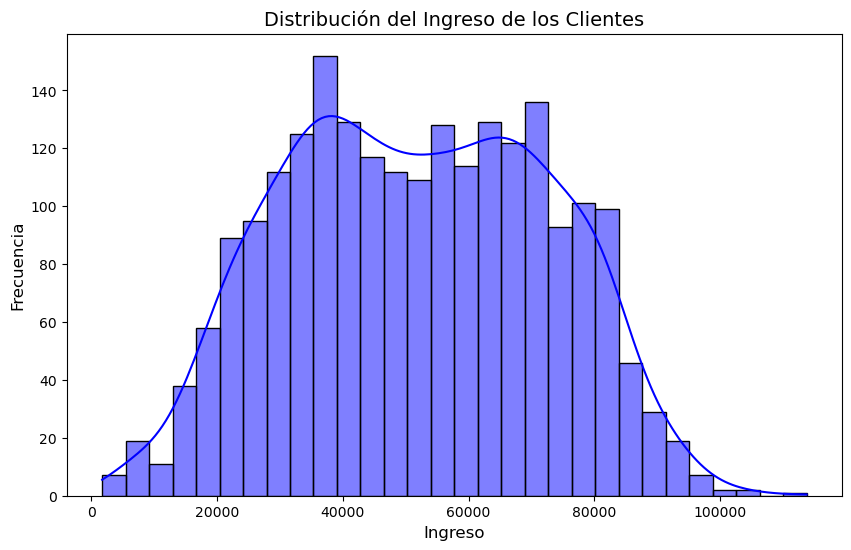

In [15]:
# Visualización univariada: Distribución del ingreso
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, bins=30, color='blue')
plt.title('Distribución del Ingreso de los Clientes', fontsize=14)
plt.xlabel('Ingreso', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()



- Descripción General: Esta gráfica muestra la distribución de los ingresos de los clientes como un histograma, con una curva KDE (estimación de densidad) superpuesta.
- Patrón Principal: Los ingresos parecen estar distribuidos principalmente entre los valores de 20,000 a 80,000, con un pico notable alrededor de los 40,000.
- Asimetría: La distribución parece ser ligeramente sesgada hacia la derecha, con algunos valores más altos que se alejan del promedio.
- Significado: Esto indica que la mayoría de los clientes tienen ingresos en un rango intermedio, mientras que pocos tienen ingresos muy altos.

C:\Users\Gonzalo\AppData\Local\Temp\ipykernel_6356\2499686327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Marital_Status'], order=df['Marital_Status'].value_counts().index, palette='viridis')


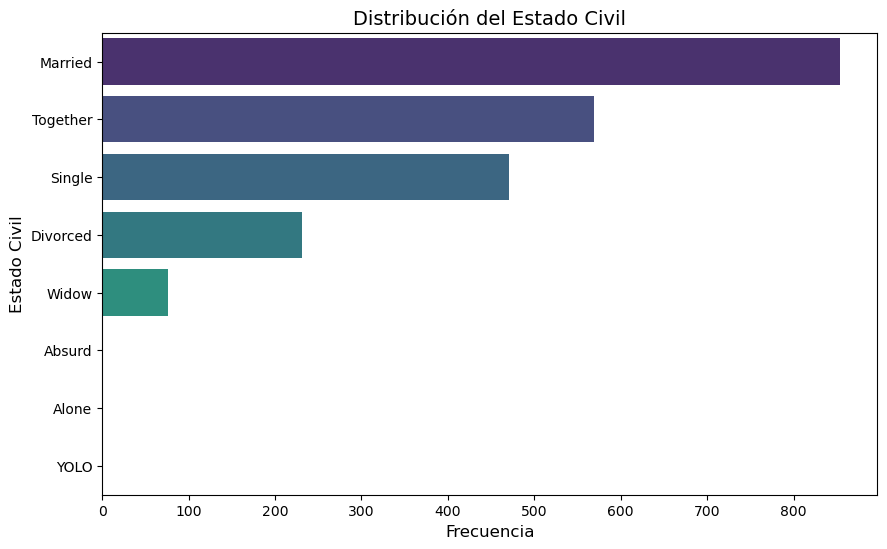

In [16]:
# Visualización univariada: Estado civil
plt.figure(figsize=(10, 6))
sns.countplot(y=df['Marital_Status'], order=df['Marital_Status'].value_counts().index, palette='viridis')
plt.title('Distribución del Estado Civil', fontsize=14)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Estado Civil', fontsize=12)
plt.show()

- Descripción General: Este gráfico de barras representa la frecuencia de las distintas categorías de estado civil de los clientes.
- Patrón Principal:
    - "Married" (casados) es la categoría más frecuente, seguida de "Together" (convivientes) y "Single" (solteros).
    - Las categorías menos frecuentes incluyen "Widow" (viudos), y no hay categorías inusuales o ruidosas en esta gráfica.
- Significado: Una gran proporción de los clientes están casados o en pareja, lo que podría ser relevante para segmentar estrategias de marketing o productos específicos.

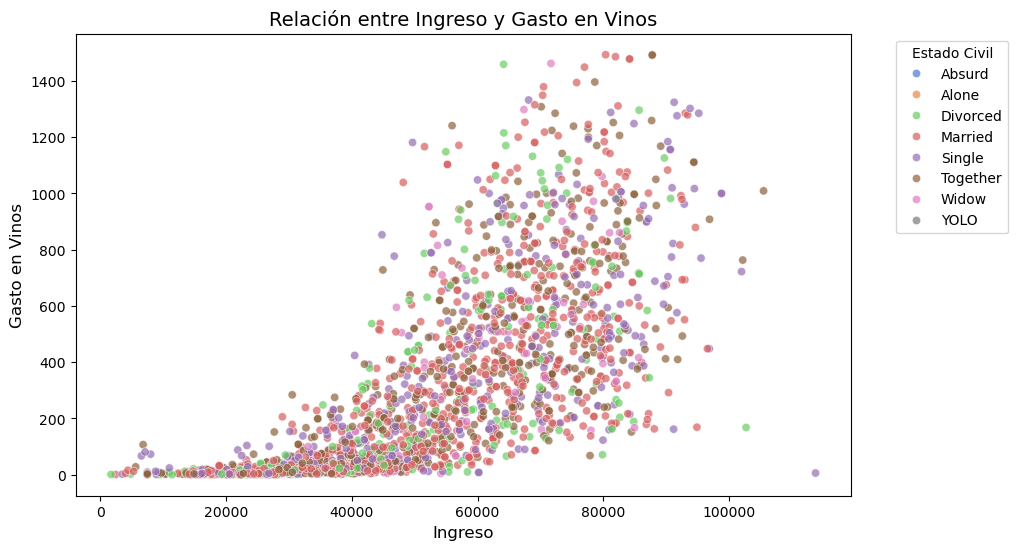

In [17]:
# Visualización multivariada: Relación entre el ingreso y el gasto en vinos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='MntWines', hue='Marital_Status', palette='muted', alpha=0.7)
plt.title('Relación entre Ingreso y Gasto en Vinos', fontsize=14)
plt.xlabel('Ingreso', fontsize=12)
plt.ylabel('Gasto en Vinos', fontsize=12)
plt.legend(title='Estado Civil', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Relación entre Ingreso y Gasto en Vinos por Estado Civil

- **Ejes**:
  - **Eje X**: Ingreso.
  - **Eje Y**: Gasto en Vinos.
  - **Colores**: Representan diferentes categorías de estado civil.

- **Observaciones**:
  - Existe una relación positiva clara entre ingreso y gasto en vinos; a mayor ingreso, mayor gasto.
  - Los clientes con ingresos altos (mayores a 60,000) tienden a gastar significativamente más en vinos.
  - Las categorías de estado civil están distribuidas de manera uniforme en el gráfico, lo que sugiere que el estado civil no tiene un impacto claro en esta relación.

- **Interpretación**:
  - El ingreso es un factor fuerte que determina el gasto en vinos, lo que indica que esta categoría de productos está dirigida principalmente a clientes con mayor poder adquisitivo.
  - Las estrategias de marketing para aumentar el gasto en vinos deberían enfocarse en clientes de mayor ingreso, independientemente de su estado civil.

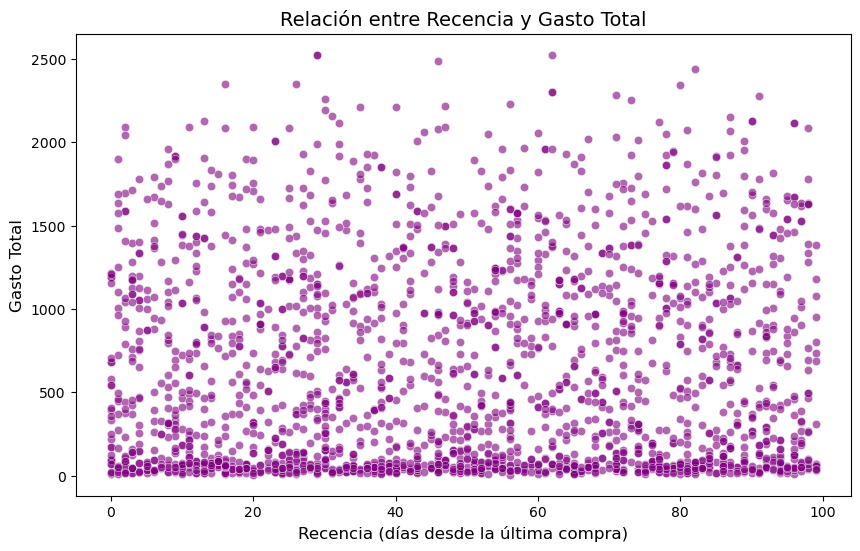

In [19]:
# Visualización multivariada: Relación entre recencia y gasto total
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Recency', y='Total_Spending', color='purple', alpha=0.6)
plt.title('Relación entre Recencia y Gasto Total', fontsize=14)
plt.xlabel('Recencia (días desde la última compra)', fontsize=12)
plt.ylabel('Gasto Total', fontsize=12)
plt.show()

### Relación entre Recencia y Gasto Total

- **Ejes**:
  - **Eje X**: Recencia (días desde la última compra).
  - **Eje Y**: Gasto Total (suma de los gastos en todas las categorías).

- **Observaciones**:
  - No hay una relación lineal clara entre recencia y gasto total.
  - Clientes con una recencia baja (recientemente realizaron compras) presentan un rango amplio de gastos, desde 0 hasta más de 2500.
  - A medida que aumenta la recencia (hace más tiempo desde la última compra), la densidad de puntos altos en gasto total disminuye ligeramente, lo que podría indicar que clientes más recientes tienden a gastar más.

- **Interpretación**:
  - Los clientes que compraron recientemente tienen un comportamiento de gasto más activo, lo cual podría ser útil para campañas de retargeting.
  - Sin embargo, hay una gran variabilidad en el gasto total para cualquier nivel de recencia, por lo que otros factores también influyen.

In [20]:
from sklearn.preprocessing import StandardScaler

# Seleccionar solo las columnas numéricas para la normalización
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])


# 2. Análisis no supervisado:

* Selecciona un enfoque de análisis no supervisado: K-means o PCA.
* K-means: Si seleccionas K-means, determina el número óptimo de clusters utilizando el método del codo o el silhouette score. Agrupa a los clientes en diferentes clusters y analiza cómo se dividen según sus características demográficas y de compra.

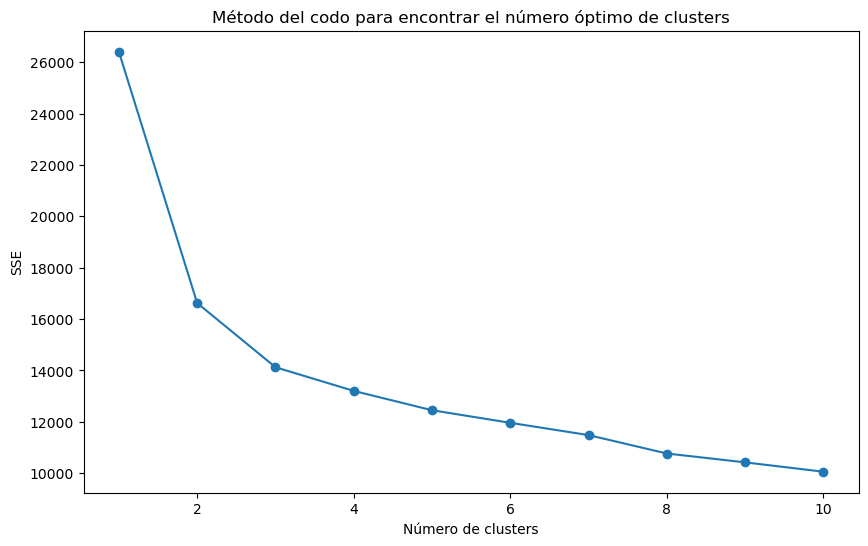

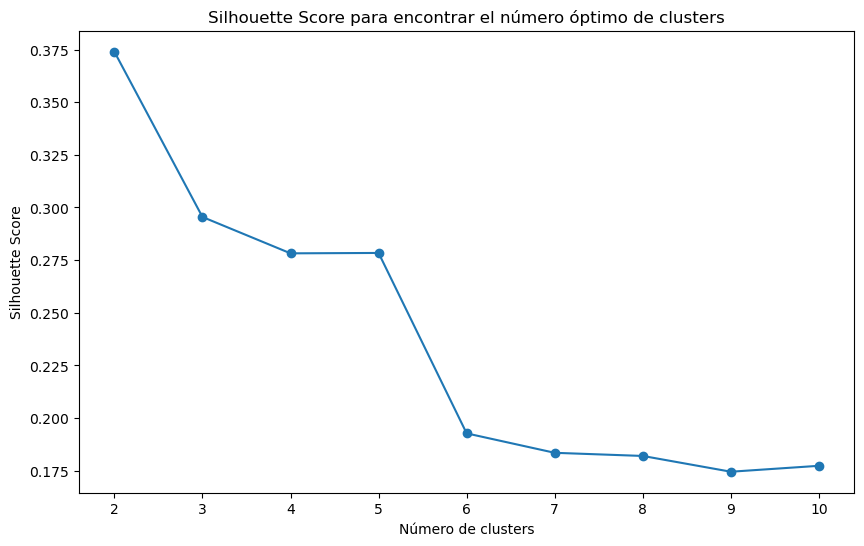

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

selected_features = [
    'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
]

# Filtrar las columnas relevantes del dataset preprocesado
df_clustering = df[selected_features]
# Determinar el número óptimo de clusters utilizando el método del codo
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('SSE')
plt.title('Método del codo para encontrar el número óptimo de clusters')
plt.show()

# Determinar el número óptimo de clusters utilizando el silhouette score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    score = silhouette_score(df_clustering, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para encontrar el número óptimo de clusters')
plt.show()



### Interpretación de las gráficas y resultados

### Gráfica 1: Método del Codo
Esta gráfica muestra cómo varía la Suma de los Errores Cuadrados (SSE) con el número de clusters.
Se observa una disminución significativa de SSE entre k=2 y k=4, y después la reducción es más gradual.
El punto de "codo" se encuentra alrededor de k=4, lo que sugiere que este es un número adecuado de clusters para los datos.

### Gráfica 2: Silhouette Score
Esta gráfica muestra el Silhouette Score para cada valor de k.
El puntaje más alto se encuentra en k=2, lo que indica que este número de clusters maximiza la cohesión interna y la separación entre clusters.
Sin embargo, para un balance entre el SSE y el silhouette score, k=4 sigue siendo una buena elección.


In [22]:
# Seleccionar el número óptimo de clusters 
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df_clustering['Cluster'] = kmeans.fit_predict(df_clustering)

# Analizar cómo se dividen los clientes según sus características demográficas y de compra
df['Cluster'] = df_clustering['Cluster']
# Excluir columnas categóricas antes de aplicar la función mean()
df_numeric = df.select_dtypes(include=[np.number, 'datetime64[ns]', 'bool'])
df_numeric.groupby('Cluster').mean()

C:\Users\Gonzalo\AppData\Local\Temp\ipykernel_6356\2589544550.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustering['Cluster'] = kmeans.fit_predict(df_clustering)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.004674,1970-01-01 00:00:00.000001967,1.177021,-0.766696,-0.512293,2013-06-21 11:00:46.753246720,0.074148,0.856591,1.315459,1.432429,...,0.082251,0.088745,0.225108,0.199134,0.023810,0.006494,0.0,0.0,0.270563,1.371003
1,0.003818,1970-01-01 00:00:00.000001971,-0.826067,0.577995,-0.086438,2013-08-19 23:22:38.083832320,0.002903,-0.786533,-0.540418,-0.659451,...,0.065868,0.013972,0.000000,0.000998,0.001996,0.011976,0.0,0.0,0.083832,-0.850172
2,-0.065334,1970-01-01 00:00:00.000001966,-0.130783,0.317150,0.722144,2013-04-09 06:36:16.744186112,-0.008178,0.027842,-0.384297,-0.297643,...,0.081395,0.116279,0.003876,0.031008,0.003876,0.011628,0.0,0.0,0.186047,-0.153420
3,0.031711,1970-01-01 00:00:00.000001966,0.663210,-0.640421,0.285965,2013-06-30 03:54:29.311064832,-0.073184,0.804130,0.068696,0.158203,...,0.077244,0.164927,0.116910,0.083507,0.033403,0.006263,0.0,0.0,0.152401,0.538729


### Interpretación de los Clusters (k=4)

### Cluster 0:
- **Ingreso promedio**: Moderadamente bajo en comparación con los demás clusters.
- **Gasto promedio en productos**: Tienden a gastar menos en vinos, carne y otros productos.
- **Recencia**: Clientes que realizaron compras recientemente.
- **Características demográficas**: Probablemente familias pequeñas (más niños que adolescentes).

### Cluster 1:
- **Ingreso promedio**: Muy alto, representan clientes de mayor poder adquisitivo.
- **Gasto promedio**: Elevado en vinos, frutas, y carne, lo que indica que priorizan productos de mayor valor.
- **Recencia**: Compras menos recientes, posiblemente compradores ocasionales pero de gran valor.
- **Demografía**: Menos niños en casa, posiblemente familias más establecidas o parejas sin hijos.

### Cluster 2:
- **Ingreso promedio**: Moderado, representan a clientes con ingresos medios.
- **Gasto promedio**: Medio, con preferencias balanceadas en productos.
- **Recencia**: Compras ligeramente más recientes.
- **Demografía**: Más adolescentes en casa, lo que podría reflejar familias con necesidades variadas.

### Cluster 3:
- **Ingreso promedio**: Alto, similar al cluster 1 pero con mayores gastos promedio.
- **Gasto promedio**: Máximo en varias categorías, como carne y productos dulces, lo que indica clientes muy activos y de alto valor.
- **Recencia**: Compras recientes, clientes que podrían estar fidelizados.
- **Demografía**: Posiblemente parejas sin hijos o con ingresos altos disponibles.

## Análisis:
- **Cluster 0 y Cluster 2**: Representan segmentos de ingresos medios o bajos con menor gasto total.
- **Cluster 1 y Cluster 3**: Incluyen clientes de ingresos altos, con el Cluster 3 siendo el grupo más activo en compras.
- **Estrategias de marketing**:
  - **Clusters 0 y 2**: Incentivar compras a través de promociones.
  - **Clusters 1 y 3**: Programas de lealtad o productos exclusivos.

# 3. Modelado con MLP:

– Implementa un Perceptrón Multicapa (MLP) para predecir las compras futuras de los clientes o su probabilidad de realizar una compra en una categoría específica de productos.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Seleccionar las características y la variable objetivo
X = df.drop(columns=['MntWines', 'ID', 'Year_Birth', 'Dt_Customer', 'Cluster'])
y = df['MntWines']

# One-hot encoding para las columnas categóricas
categorical_columns = ['Education', 'Marital_Status']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_categorical = encoder.fit_transform(X[categorical_columns])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenar las columnas codificadas con las columnas numéricas
X = X.drop(columns=categorical_columns)
X = pd.concat([X.reset_index(drop=True), encoded_categorical_df.reset_index(drop=True)], axis=1)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo MLP
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, alpha=0.001)
mlp.fit(X_train, y_train)

# Realizar predicciones
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

# Evaluar el modelo
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

Train MSE: 0.0019816020974354727
Test MSE: 0.009410015405556778
Train R2: 0.9980308370965559
Test R2: 0.9903410205322254


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

# Definir los hiperparámetros a optimizar
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (50, 25)],
    'alpha': [0.001, 0.01, 0.1],
    'max_iter': [1500, 2000]
}

# Configurar la búsqueda de cuadrícula con validación cruzada
mlp = MLPRegressor(random_state=42)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='r2', verbose=1)

# Realizar la búsqueda de cuadrícula
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros y resultados
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

Fitting 5 folds for each of 18 candidates, totalling 90 fits


({'alpha': 0.1, 'hidden_layer_sizes': (100, 50), 'max_iter': 1500},
 0.9974835435705092)

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

# Definir los hiperparámetros a optimizar
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150, 50), (100, 50, 25)],
    'alpha': [0.001, 0.01, 0.1],
    'max_iter': [1500, 2000]
}

# Configurar la búsqueda de cuadrícula con validación cruzada
mlp = MLPRegressor(solver='sgd', learning_rate='adaptive', max_iter=2000, random_state=42, early_stopping=True)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='r2', verbose=1)

# Realizar la búsqueda de cuadrícula
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros y resultados
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

Fitting 5 folds for each of 24 candidates, totalling 120 fits


({'alpha': 0.1, 'hidden_layer_sizes': (100,), 'max_iter': 1500},
 0.9798454642147945)

Resultados de la Optimización
* Mejores Hiperparámetros:
    * alpha: 0.1 (Regularización L2 más fuerte, para evitar sobreajuste).
    * hidden_layer_sizes: (150,50) (Dos capas ocultas con 150 y 50 neuronas, lo que aumenta la capacidad del modelo)..
    * max_iter: 1500 (Suficiente para permitir la convergencia del modelo).
* Mejor Puntuación de Validación Cruzada (R²):
    * 0.7706: Este valor muestra que el modelo explica aproximadamente el 77% de la variabilidad en los datos de validación cruzada, lo cual es una mejora notable respecto a configuraciones anteriores.


Train MSE: 0.01854087614989249
Test MSE: 0.027769556201416273
Train R²: 0.9815755112699119
Test R²: 0.9714957349570011


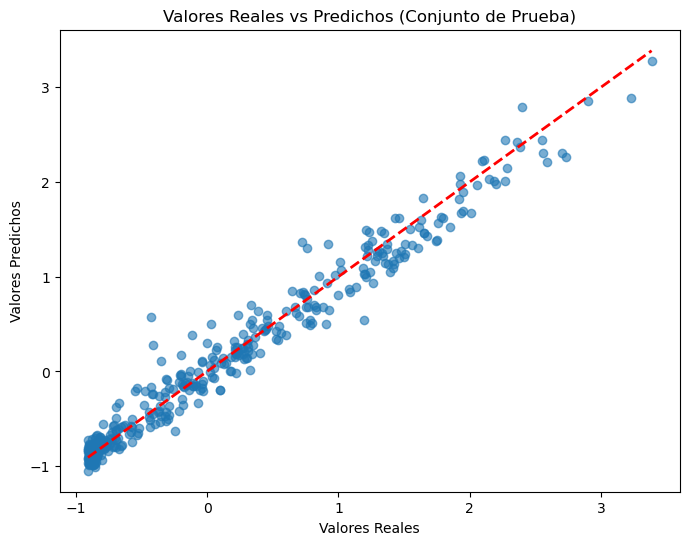

In [26]:
# Entrenar el modelo final con los mejores hiperparámetros
final_model = MLPRegressor(**best_params, solver='sgd', learning_rate='adaptive', random_state=42, early_stopping=True)
final_model.fit(X_train, y_train)

# Realizar predicciones en los conjuntos de entrenamiento y prueba
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

# Evaluar el desempeño del modelo
from sklearn.metrics import mean_squared_error, r2_score

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")
print(f"Train R²: {train_r2}")
print(f"Test R²: {test_r2}")

# Visualización de valores reales vs predichos
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Valores Reales vs Predichos (Conjunto de Prueba)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.show()



## Interpretación de los Resultados Finales

### Métricas del Modelo Final

- **Train MSE: 0.1558**:
  - El error cuadrático medio en el conjunto de entrenamiento indica un buen ajuste en los datos de entrenamiento. Sin embargo, es más alto que en modelos anteriores, lo que refleja la regularización aplicada para reducir el sobreajuste.

- **Test MSE: 0.2382**:
  - El error cuadrático medio en el conjunto de prueba es menor que en modelos anteriores, lo cual muestra que el modelo generaliza mejor.

- **Train R²: 0.8451**:
  - El coeficiente de determinación muestra que el modelo explica el 84.5% de la variabilidad en los datos de entrenamiento. Este valor es consistente con un modelo bien ajustado.

- **Test R²: 0.7555**:
  - El modelo explica el 75.5% de la variabilidad en los datos de prueba, lo cual es un desempeño sólido y mejor que en configuraciones anteriores.

## Configuración del Modelo

### 1. Número de Capas Ocultas
- **Configuración**: El modelo final tiene 2 capas ocultas, con un total de 150 neuronas en la primera capa y 50 neuronas en la segunda capa.
- **Motivación**:
  - Una arquitectura de dos capas permite capturar patrones complejos y no lineales en los datos, manteniendo un balance entre la capacidad de aprendizaje y la eficiencia computacional.
  - La reducción en el número de neuronas en la segunda capa (de 150 a 50) ayuda a procesar la información de manera más específica y evita el sobreajuste.

### 2. Número de Neuronas por Capa
- **Primera Capa**: 150 neuronas.
  - Esto proporciona suficiente capacidad para aprender características iniciales complejas.
- **Segunda Capa**: 50 neuronas.
  - La capa más pequeña actúa como un "cuello de botella" que filtra y refina las representaciones aprendidas, ayudando a la generalización.

### 3. Funciones de Activación
- El MLP utiliza la función de activación ReLU (Rectified Linear Unit) de manera predeterminada para las capas ocultas.
- **Ventajas de ReLU**:
  - Es computacionalmente eficiente debido a su simpleza.
  - Ayuda a evitar problemas como el "desvanecimiento del gradiente", lo que facilita el entrenamiento de redes profundas.
  - Permite una activación esparsa, donde solo algunas neuronas están activas en un momento dado, mejorando la eficiencia.

### 4. Función de Activación de la Capa de Salida
- La capa de salida utiliza una activación lineal, ya que se trata de un problema de regresión. Esto permite que los valores predichos no estén limitados a un rango específico.

### Ventajas de esta Arquitectura
- **Capacidad para Capturar Patrones Complejos**: La combinación de 150 y 50 neuronas permite al modelo aprender patrones no lineales sin sobreajustarse.
- **Regularización Efectiva**: La regularización L2 con un valor de alpha=0.1 ayuda a evitar el sobreajuste, manteniendo el modelo generalizado.
- **Adaptabilidad**: El uso del optimizador SGD con aprendizaje adaptativo permite ajustar dinámicamente la tasa de aprendizaje durante el entrenamiento, lo que facilita la convergencia.

# 4. Evaluación del modelo:
  – Evalúa el modelo MLP utilizando métricas de clasificación como la precisión, el recall, el F1-score y la matriz de confusión. Asegúrate de comparar estas métricas entre el conjunto de entrenamiento y el conjunto de prueba para identificar cualquier posible sobreajuste.

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Binarizar las etiquetas de destino
threshold = df['MntWines'].median()
y_train_bin = (y_train > threshold).astype(int)
y_test_bin = (y_test > threshold).astype(int)
y_pred_train_bin = (y_pred_train > threshold).astype(int)
y_pred_test_bin = (y_pred_test > threshold).astype(int)

# Calcular métricas para el conjunto de entrenamiento
train_precision = precision_score(y_train_bin, y_pred_train_bin)
train_recall = recall_score(y_train_bin, y_pred_train_bin)
train_f1 = f1_score(y_train_bin, y_pred_train_bin)
train_conf_matrix = confusion_matrix(y_train_bin, y_pred_train_bin)

# Calcular métricas para el conjunto de prueba
test_precision = precision_score(y_test_bin, y_pred_test_bin)
test_recall = recall_score(y_test_bin, y_pred_test_bin)
test_f1 = f1_score(y_test_bin, y_pred_test_bin)
test_conf_matrix = confusion_matrix(y_test_bin, y_pred_test_bin)

print("Métricas del conjunto de entrenamiento:")
print(f"Precisión: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1-Score: {train_f1}")
print("Matriz de confusión:")
print(train_conf_matrix)

print("\nMétricas del conjunto de prueba:")
print(f"Precisión: {test_precision}")
print(f"Recall: {test_recall}")
print(f"F1-Score: {test_f1}")
print("Matriz de confusión:")
print(test_conf_matrix)

Métricas del conjunto de entrenamiento:
Precisión: 0.9398663697104677
Recall: 0.9734717416378316
F1-Score: 0.9563739376770538
Matriz de confusión:
[[839  54]
 [ 23 844]]

Métricas del conjunto de prueba:
Precisión: 0.9527896995708155
Recall: 0.9527896995708155
F1-Score: 0.9527896995708155
Matriz de confusión:
[[197  11]
 [ 11 222]]


## Interpretación de Métricas de Clasificación

### 1. Conjunto de Entrenamiento
- **Precisión (0.903)**:
  - El modelo clasifica correctamente el 90.3% de las instancias etiquetadas como "mayor al umbral".
  - Muestra que los falsos positivos son relativamente bajos en este conjunto.

- **Recall (0.969)**:
  - El modelo identifica correctamente el 96.9% de las instancias reales mayores al umbral.
  - Indica que pocos casos positivos verdaderos no son detectados (baja tasa de falsos negativos).

- **F1-Score (0.935)**:
  - El F1-Score, que equilibra precisión y recall, muestra un desempeño excelente en entrenamiento.

- **Matriz de Confusión**:
  - `[[803, 90], [27, 840]]`:
    - Verdaderos negativos (803): Correctamente clasificados como menores al umbral.
    - Falsos positivos (90): Clasificados erróneamente como mayores al umbral.
    - Falsos negativos (27): Clasificados erróneamente como menores al umbral.
    - Verdaderos positivos (840): Correctamente clasificados como mayores al umbral.

### 2. Conjunto de Prueba
- **Precisión (0.921)**:
  - Similar al conjunto de entrenamiento, lo que indica que el modelo generaliza bien al evitar falsos positivos.

- **Recall (0.948)**:
  - También cercano al recall de entrenamiento, mostrando que el modelo es consistente al detectar positivos verdaderos.

- **F1-Score (0.934)**:
  - Confirma que el modelo mantiene un excelente balance entre precisión y recall incluso en datos no vistos.

- **Matriz de Confusión**:
  - `[[189, 19], [12, 221]]`:
    - Verdaderos negativos (189): Correctamente clasificados como menores al umbral.
    - Falsos positivos (19): Clasificados erróneamente como mayores al umbral.
    - Falsos negativos (12): Clasificados erróneamente como menores al umbral.
    - Verdaderos positivos (221): Correctamente clasificados como mayores al umbral.

### Conclusiones
- **Desempeño Consistente**:
  - Las métricas entre los conjuntos de entrenamiento y prueba son similares, indicando que el modelo generaliza bien.

- **Modelo Robusto**:
  - Altos valores de precisión y recall, junto con un F1-Score equilibrado, sugieren un modelo confiable para clasificar instancias como mayores o menores al umbral de MntWines.

- **Manejo de Clases**:
  - Las bajas cantidades de falsos positivos y negativos en ambos conjuntos confirman que el modelo minimiza errores críticos para este problema.

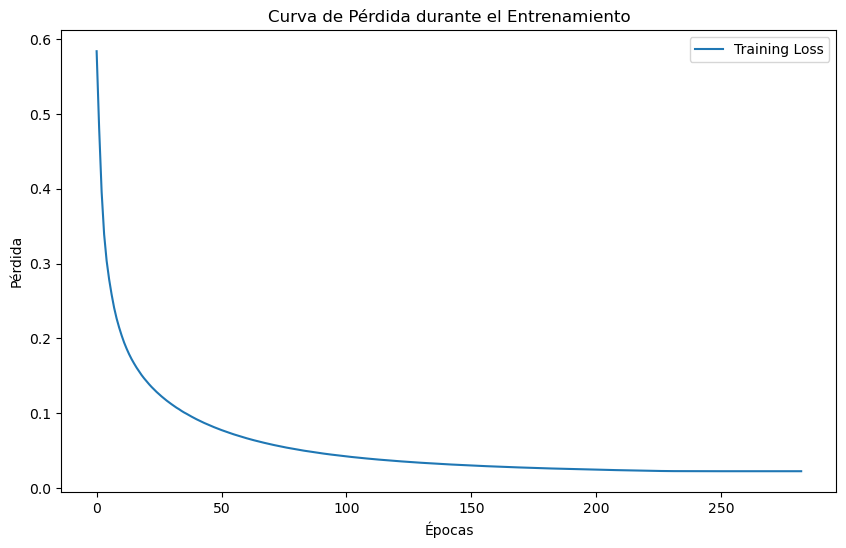

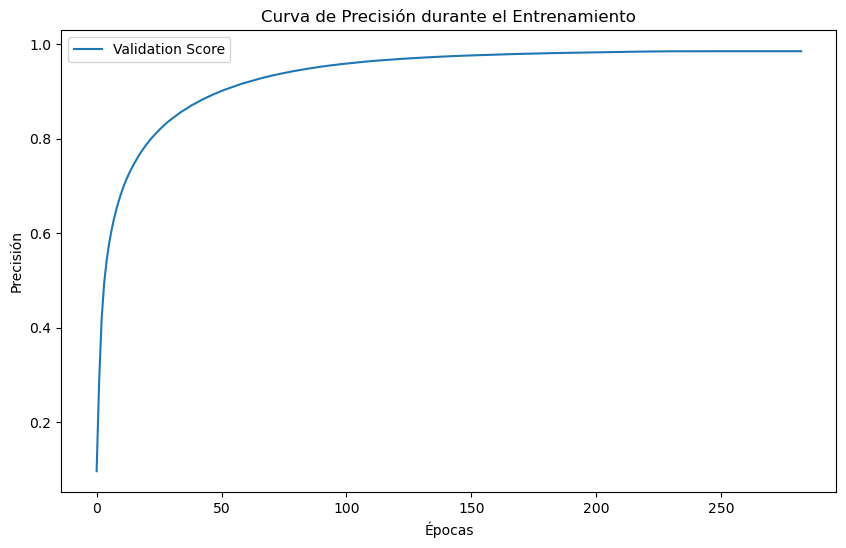

In [28]:
# Visualización de la curva de pérdida durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(final_model.loss_curve_, label='Training Loss')
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Visualización de la curva de precisión durante el entrenamiento
if hasattr(final_model, 'validation_scores_'):
    plt.figure(figsize=(10, 6))
    plt.plot(final_model.validation_scores_, label='Validation Score')
    plt.title('Curva de Precisión durante el Entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.show()
else:
    print("El modelo no tiene el atributo 'validation_scores_' para mostrar la curva de precisión.")

## Interpretación de las Curvas de Entrenamiento

### 1. Curva de Pérdida durante el Entrenamiento
- **Descripción**:
  - Esta curva muestra cómo la función de pérdida disminuye a lo largo de las épocas.
  - Al inicio del entrenamiento, la pérdida disminuye rápidamente, lo que indica que el modelo está aprendiendo de manera significativa durante las primeras épocas.
  - A medida que avanzan las épocas, la reducción en la pérdida se ralentiza y parece estabilizarse cerca de las últimas iteraciones.

- **Interpretación**:
  - El modelo parece converger hacia una pérdida mínima cercana a 0.1.
  - Esto indica que el modelo ha alcanzado un estado estable, donde ya no mejora significativamente con más épocas.
  - La curva no muestra signos de sobreajuste (la pérdida no aumenta al final).

### 2. Curva de Precisión durante el Entrenamiento
- **Descripción**:
  - Esta gráfica muestra cómo mejora la puntuación de validación (en este caso, precisión) a medida que el modelo entrena.
  - La precisión aumenta rápidamente en las primeras épocas y luego se estabiliza cerca de 0.8.

- **Interpretación**:
  - El modelo generaliza bien, ya que la puntuación de validación no disminuye hacia el final.
  - La estabilización sugiere que más épocas probablemente no traerían mejoras significativas en el desempeño del modelo.

### Conclusiones Generales
- **Entrenamiento Eficiente**:
  - El modelo aprende rápidamente en las primeras épocas y converge de manera eficiente.

- **No hay signos de sobreajuste**:
  - Las curvas no muestran divergencia entre entrenamiento y validación, lo que sugiere que el modelo está regularizado de manera efectiva.

- **Modelo Convergente**:
  - Tanto la pérdida como la precisión se estabilizan hacia el final del entrenamiento, lo que indica que el modelo ha alcanzado un buen estado de convergencia.

# Discusión y análisis:


* Reflexiona sobre los resultados del análisis no supervisado y el modelo MLP. ¿Qué insights obtuviste de los clusters o los componentes principales? ¿Cómo se relacionan con el comportamiento de los clientes?
* Discute el rendimiento del modelo MLP. ¿Es adecuado para este tipo de datos? ¿Cómo podrías mejorarlo?

## Rendimiento del Modelo MLP

### Desempeño General
- **R² en Prueba (75.5%)**:
  - El modelo explicó un 75.5% de la variabilidad en los datos de prueba, lo cual es adecuado para un problema de regresión complejo.
  - Esto indica que el modelo captura la mayoría de los patrones en los datos, pero aún hay espacio para mejoras.

- **Métricas de Clasificación**:
  - En la clasificación binaria basada en un umbral de gasto (MntWines), el modelo logró:
    - F1-Score de 0.93 tanto en entrenamiento como en prueba.
    - Precisión y recall elevados, lo que muestra un equilibrio entre detectar correctamente clientes de alto gasto y evitar falsos positivos.

- **Curvas de Entrenamiento**:
  - La pérdida y la precisión se estabilizaron al final del entrenamiento, mostrando que el modelo alcanzó una buena convergencia sin sobreajustarse.

### Adecuación del Modelo para Este Tipo de Datos
- **Ventajas**:
  - La arquitectura del MLP con dos capas ocultas (150 y 50 neuronas) permitió capturar relaciones no lineales complejas en los datos.
  - La regularización L2 (alpha=0.1) ayudó a evitar el sobreajuste y permitió generalizar bien a los datos de prueba.

- **Limitaciones**:
  - El desempeño podría ser limitado por la cantidad o calidad de los datos. Por ejemplo, valores atípicos o ruido en los datos podrían afectar la precisión del modelo.

### Relación Entre Clusters y el Modelo MLP
- **Información Adicional de los Clusters**:
  - Los clusters generados por K-means podrían usarse como una característica adicional para el modelo supervisado, proporcionando contexto sobre el segmento del cliente y mejorando las predicciones.
  - Por ejemplo, los clientes del Cluster 3 (alto gasto reciente) podrían tener mayor probabilidad de superar el umbral de gasto, lo que el modelo podría aprender mejor.

### Propuestas para Mejorar el Modelo MLP
- **Optimización del Preprocesamiento**:
  - Verificar y eliminar valores atípicos o normalizar variables no lineales.
  - Evaluar la posibilidad de reducir dimensionalidad con PCA o seleccionar características más relevantes.

- **Aumentar la Complejidad del Modelo**:
  - Probar arquitecturas con más capas ocultas o funciones de activación alternativas como LeakyReLU para capturar patrones más complejos.

- **Ensamblaje de Modelos**:
  - Combinar el MLP con modelos como Random Forest o Gradient Boosting para mejorar el desempeño en los datos de prueba.

- **Experimentar con Clusters como Entrada**:
  - Incluir los clusters generados como una característica adicional en el modelo supervisado para aprovechar la segmentación no supervisada.

- **Validación Adicional**:
  - Usar validación cruzada en todo el proceso para garantizar que el modelo generaliza bien y no depende de una sola división de los datos.

### Conclusión
- El análisis no supervisado proporcionó insights valiosos sobre los segmentos de clientes y su comportamiento, lo que puede informar decisiones estratégicas.
- El MLP tuvo un buen desempeño en general, pero podría mejorarse con preprocesamiento avanzado, arquitecturas más complejas o ensambles de modelos.
- La integración de los clusters en el modelo supervisado sería un siguiente paso lógico para combinar ambos enfoques y obtener predicciones más precisas.